## 1. Data Collection

In [1]:
import pandas as pd
import subprocess, sys, os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
webScraper = "download_iemop.py"
subprocess.run([sys.executable, webScraper])

Identifying server path...
Scanning for available CSVs...
Files found: 180 | Current scan: 20251025

In [ ]:
data = "iemop_combined.csv"

df = pd.read_csv(data)
df

,RUN_TIME,MKT_TYPE,TIME_INTERVAL,REGION_NAME,RESOURCE_NAME,RESOURCE_TYPE,COMMODITY_TYPE,MARGINAL_PRICE,Unnamed: 8
0,10/20/2025,RTD,10/20/2025 12:05:00 AM,CLUZ,02TMOBIL_G03,G,Dr,910.0000,NaN
1,10/20/2025,RTD,10/20/2025 12:05:00 AM,CLUZ,03BACMAN_BAT,G,Rd,3399.9996,NaN
2,10/20/2025,RTD,10/20/2025 12:05:00 AM,CLUZ,03BACMAN_BAT,G,Ru,3419.5816,NaN
3,10/20/2025,RTD,10/20/2025 12:05:00 AM,CLUZ,03INGRID_GS5,G,Fr,3619.5382,NaN
4,10/20/2025,RTD,10/20/2025 12:05:00 AM,CVIS,05CARMENDPP_U03,G,Dr,2000.0004,NaN
...,...,...,...,...,...,...,...,...,...
632250,4/22/2026 11:55:00 PM,RTD,4/23/2026,CMIN,09WMPC_U02,G,Dr,0.0000,NaN
632251,4/22/2026 11:55:00 PM,RTD,4/23/2026,CMIN,10AGUS1_U01,G,Fr,0.0000,NaN
632252,4/22/2026 11:55:00 PM,RTD,4/23/2026,CMIN,11JASA_BAT,G,Rd,1000.0000,NaN
632253,4/22/2026 11:55:00 PM,RTD,4/23/2026,CMIN,13MALITA_BAT,G,Ru,0.0000,NaN


In [ ]:
df.dtypes

RUN_TIME           object
MKT_TYPE           object
TIME_INTERVAL      object
REGION_NAME        object
RESOURCE_NAME      object
RESOURCE_TYPE      object
COMMODITY_TYPE     object
MARGINAL_PRICE    float64
Unnamed: 8        float64
dtype: object

## 2. Data Preparation

In [ ]:
df = df.drop(columns=['Unnamed: 8'])

In [ ]:
df.columns = df.columns.str.lower()
df

,run_time,mkt_type,time_interval,region_name,resource_name,resource_type,commodity_type,marginal_price
0,10/20/2025,RTD,10/20/2025 12:05:00 AM,CLUZ,02TMOBIL_G03,G,Dr,910.0000
1,10/20/2025,RTD,10/20/2025 12:05:00 AM,CLUZ,03BACMAN_BAT,G,Rd,3399.9996
2,10/20/2025,RTD,10/20/2025 12:05:00 AM,CLUZ,03BACMAN_BAT,G,Ru,3419.5816
3,10/20/2025,RTD,10/20/2025 12:05:00 AM,CLUZ,03INGRID_GS5,G,Fr,3619.5382
4,10/20/2025,RTD,10/20/2025 12:05:00 AM,CVIS,05CARMENDPP_U03,G,Dr,2000.0004
...,...,...,...,...,...,...,...,...
632250,4/22/2026 11:55:00 PM,RTD,4/23/2026,CMIN,09WMPC_U02,G,Dr,0.0000
632251,4/22/2026 11:55:00 PM,RTD,4/23/2026,CMIN,10AGUS1_U01,G,Fr,0.0000
632252,4/22/2026 11:55:00 PM,RTD,4/23/2026,CMIN,11JASA_BAT,G,Rd,1000.0000
632253,4/22/2026 11:55:00 PM,RTD,4/23/2026,CMIN,13MALITA_BAT,G,Ru,0.0000


In [ ]:
features = ['time_interval', 'region_name', 'commodity_type', 'resource_type', 'marginal_price', 'resource_name']
df = df[features]
df

,time_interval,region_name,commodity_type,resource_type,marginal_price,resource_name
0,10/20/2025 12:05:00 AM,CLUZ,Dr,G,910.0000,02TMOBIL_G03
1,10/20/2025 12:05:00 AM,CLUZ,Rd,G,3399.9996,03BACMAN_BAT
2,10/20/2025 12:05:00 AM,CLUZ,Ru,G,3419.5816,03BACMAN_BAT
3,10/20/2025 12:05:00 AM,CLUZ,Fr,G,3619.5382,03INGRID_GS5
4,10/20/2025 12:05:00 AM,CVIS,Dr,G,2000.0004,05CARMENDPP_U03
...,...,...,...,...,...,...
632250,4/23/2026,CMIN,Dr,G,0.0000,09WMPC_U02
632251,4/23/2026,CMIN,Fr,G,0.0000,10AGUS1_U01
632252,4/23/2026,CMIN,Rd,G,1000.0000,11JASA_BAT
632253,4/23/2026,CMIN,Ru,G,0.0000,13MALITA_BAT


In [ ]:
# df['RUN_TIME'] = pd.to_datetime(df['RUN_TIME'], errors='coerce')
df['time_interval'] = pd.to_datetime(df['time_interval'], errors='coerce')

reserve_map = {'Dr': 'Dispatchable', 
               'Rd': 'Regulating down', 
               'Ru': 'Regulating up', 
               'Fr': 'Contingency'
               }

df['commodity_type'] = df['commodity_type'].map(reserve_map).fillna(df['commodity_type'])

/tmp/ipykernel_16526/312703286.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time_interval'] = pd.to_datetime(df['time_interval'], errors='coerce')
/tmp/ipykernel_16526/312703286.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time_interval'] = pd.to_datetime(df['time_interval'], errors='coerce')
/tmp/ipykernel_16526/312703286.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retur

In [ ]:
df['resource_type'].value_counts()

resource_map = {
    'G': 'Generator',
    'PS': 'Pumped storage'
    }

df['resource_type'] = df['resource_type'].map(resource_map).fillna(df['resource_type'])

/tmp/ipykernel_16526/4045381422.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['resource_type'] = df['resource_type'].map(resource_map).fillna(df['resource_type'])


In [ ]:
df['commodity_type'] = df['commodity_type'].str.title()
df['resource_type'] = df['resource_type'].str.title()

region_map = {
    'CLUZ': 'Luzon',
    'CVIS': 'Visayas',
    'CMIN': 'Mindanao'
}

df['region_name'] = df['region_name'].map(region_map).fillna(df['region_name'])

/tmp/ipykernel_16526/2362516347.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['commodity_type'] = df['commodity_type'].str.title()
/tmp/ipykernel_16526/2362516347.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['resource_type'] = df['resource_type'].str.title()
/tmp/ipykernel_16526/2362516347.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

In [ ]:
df['is_battery'] = df['resource_name'].str.contains('_BAT', case=False)
df = df.sort_values(by=['time_interval', 'region_name']).reset_index(drop=True)

/tmp/ipykernel_16526/471652990.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_battery'] = df['resource_name'].str.contains('_BAT', case=False)


In [ ]:
df = df.iloc[:-1]
df = df.drop_duplicates(subset=['time_interval', 'resource_name', 'commodity_type']).dropna()
print(df.isna().sum())

time_interval     0
region_name       0
commodity_type    0
resource_type     0
marginal_price    0
resource_name     0
is_battery        0
dtype: int64


In [ ]:
df

,time_interval,region_name,commodity_type,resource_type,marginal_price,resource_name,is_battery
0,2025-10-20 00:05:00,Luzon,Dispatchable,Generator,910.0000,02TMOBIL_G03,False
1,2025-10-20 00:05:00,Luzon,Regulating Down,Generator,3399.9996,03BACMAN_BAT,True
2,2025-10-20 00:05:00,Luzon,Regulating Up,Generator,3419.5816,03BACMAN_BAT,True
3,2025-10-20 00:05:00,Luzon,Contingency,Generator,3619.5382,03INGRID_GS5,False
4,2025-10-20 00:05:00,Mindanao,Contingency,Generator,1.0000,10AGUS1_U02,False
...,...,...,...,...,...,...,...
632067,2026-04-23 00:00:00,Mindanao,Regulating Up,Generator,0.0000,13MALITA_BAT,True
632068,2026-04-23 00:00:00,Visayas,Dispatchable,Generator,0.0000,05CARMENDPP_U02,False
632069,2026-04-23 00:00:00,Visayas,Contingency,Generator,0.0000,05TPC_G02,False
632070,2026-04-23 00:00:00,Visayas,Regulating Down,Generator,0.0000,06PAL2A_U03,False


In [ ]:
df.info

<bound method DataFrame.info of              time_interval region_name   commodity_type resource_type  \
0      2025-10-20 00:05:00       Luzon     Dispatchable     Generator   
1      2025-10-20 00:05:00       Luzon  Regulating Down     Generator   
2      2025-10-20 00:05:00       Luzon    Regulating Up     Generator   
3      2025-10-20 00:05:00       Luzon      Contingency     Generator   
4      2025-10-20 00:05:00    Mindanao      Contingency     Generator   
...                    ...         ...              ...           ...   
632067 2026-04-23 00:00:00    Mindanao    Regulating Up     Generator   
632068 2026-04-23 00:00:00     Visayas     Dispatchable     Generator   
632069 2026-04-23 00:00:00     Visayas      Contingency     Generator   
632070 2026-04-23 00:00:00     Visayas  Regulating Down     Generator   
632071 2026-04-23 00:00:00     Visayas    Regulating Up     Generator   

        marginal_price    resource_name is_battery  
0             910.0000     02TMOBIL_G0

In [ ]:
print(df.groupby('commodity_type')['marginal_price'].agg(['min', 'max', 'mean']))

                 min      max          mean
commodity_type                             
Contingency      0.0  25000.0   4733.260215
Dispatchable     0.0  25000.0   1592.683555
Regulating Down  0.0  25000.0  13613.119350
Regulating Up    0.0  25000.0  13644.147562


## 3. Exploratory Data Analysis

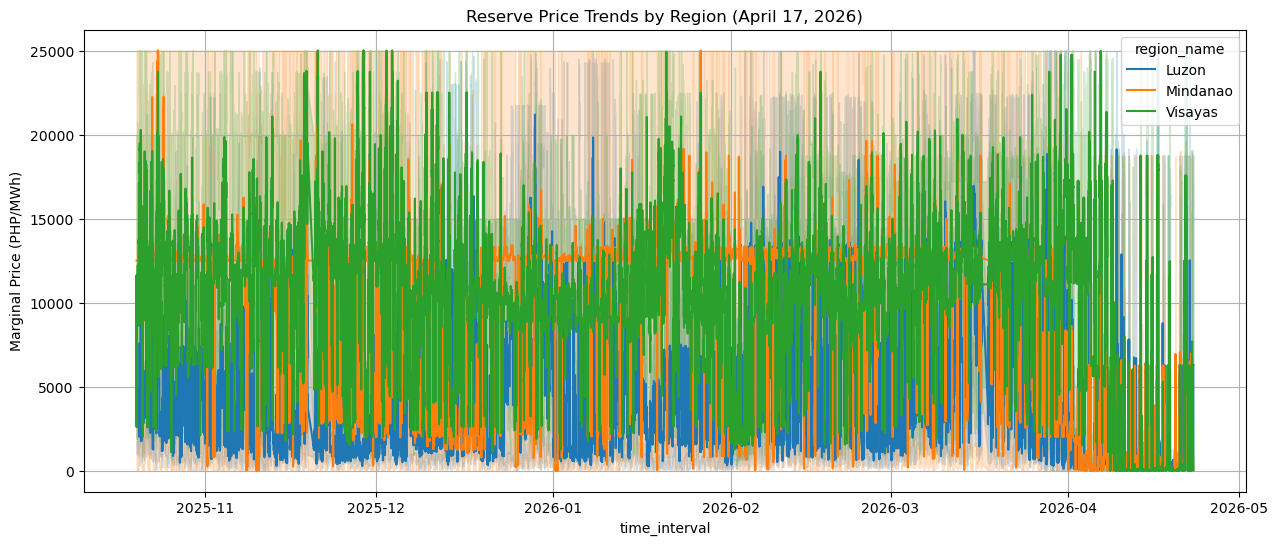

In [ ]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=df, x='time_interval', y='marginal_price', hue='region_name')
plt.title('Reserve Price Trends by Region (April 17, 2026)')
plt.ylabel('Marginal Price (PHP/MWh)')
plt.grid(True)
plt.show()

In [ ]:
top_setters = df['resource_name'].value_counts().head(10)
print("Top 10 Price-Setting Resources:\n", top_setters)

Top 10 Price-Setting Resources:
 resource_name
11JASA_BAT      39651
11VILLA_BAT     34966
03EERI_G03      34134
06SONEG_BAT     32142
13MACO_BAT      29566
04TONGO_BAT     16444
03BACMAN_BAT    13205
08PEDC_U03      12395
04IASMOD_G05    11682
05CEDC_U01      10600
Name: count, dtype: int64
